<a href="https://colab.research.google.com/github/clobos/Biologia_2026/blob/main/semana03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# SIMETRIA E ASSIMETRIA EM DADOS BIOLÓGICOS

**Objetivo**

Criar três conjuntos de dados simulados da área de Biologia:

 1. Distribuição aproximadamente simétrica: Comprimento corporal de indivíduos de uma mesma população.

 2. Distribuição com assimetria à direita: Número de sementes produzidas por plantas.

 3. Distribuição com assimetria à esquerda: Percentual de sobrevivência de larvas em diferentes recipientes.

 Para cada variável serão mostrados:
 - Histograma: revela a forma geral da distribuição.
 - Boxplot: resume mediana, quartis, dispersão e possíveis valores extremos.

 Bibliotecas necessárias:
 numpy      -> simulação dos dados numéricos.
 matplotlib -> construção dos gráficos.
 seaborn    -> melhoria estética dos gráficos estatísticos.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# CONFIGURAÇÕES INICIAIS
# ------------------------------------------------------------

# Define uma semente para o gerador de números aleatórios.
# Isso torna os resultados reproduzíveis: ao executar novamente
# o código, os mesmos dados simulados serão obtidos.
np.random.seed(2026)

# Define um estilo visual mais agradável para os gráficos.
sns.set_theme(style="whitegrid", context="notebook")

# Número de unidades experimentais ou observações em cada exemplo.
# Aqui, cada conjunto terá dados de 300 organismos, plantas ou recipientes.
n = 300




# DISTRIBUIÇÃO SIMÉTRICA

In [2]:
# Variável biológica:
# comprimento_corporal_mm
#
# Interpretação:
# Representa o comprimento corporal, em milímetros, de 300 indivíduos
# adultos de uma mesma espécie de besouro coletados em uma área.
#
# Justificativa biológica:
# Características biométricas, como comprimento corporal, massa ou altura,
# frequentemente apresentam distribuição aproximadamente normal quando:
# - os indivíduos pertencem a uma população relativamente homogênea;
# - a característica é influenciada por muitos pequenos fatores;
# - não há forte limitação inferior ou superior observada na amostra.
#
# Distribuição usada:
# normal(loc=18, scale=2)
#
# loc = média populacional simulada = 18 mm.
# scale = desvio-padrão populacional simulado = 2 mm.
#
# Espera-se:
# média ≈ mediana;
# caudas semelhantes à esquerda e à direita;
# histograma com formato de sino aproximadamente equilibrado.
# ============================================================

comprimento_corporal_mm = np.random.normal(
    loc=18,       # Média do comprimento corporal: 18 mm
    scale=2,      # Desvio-padrão: 2 mm
    size=n        # Número de besouros observados: 300
)




# DISTRIBUIÇÃO COM ASSIMETRIA À DIREITA

In [3]:
# Variável biológica:
# numero_sementes
#
# Interpretação:
# Representa o número de sementes produzidas por 300 plantas individuais
# de uma espécie vegetal em uma parcela experimental.
#
# Justificativa biológica:
# Dados de produção biológica frequentemente apresentam assimetria à direita.
# Muitas plantas podem produzir poucas ou moderadas quantidades de sementes,
# enquanto poucas plantas, com condições especialmente favoráveis, produzem
# quantidades muito elevadas.
#
# Distribuição usada:
# lognormal(mean=3.7, sigma=0.65)
#
# A distribuição lognormal gera apenas valores positivos, sendo adequada para
# variáveis como biomassa, abundância, concentração, contagem de propágulos,
# produção de frutos e número de sementes.
#
# Espera-se:
# média > mediana;
# cauda longa no lado direito;
# alguns valores altos, visualizados como possíveis outliers no boxplot.
# ============================================================

numero_sementes = np.random.lognormal(
    mean=3.7,     # Parâmetro da escala logarítmica; controla a posição dos dados
    sigma=0.65,   # Dispersão na escala logarítmica; aumenta a assimetria
    size=n        # Número de plantas avaliadas: 300
)

# Como "número de sementes" é uma contagem, arredondamos para valores inteiros.
numero_sementes = np.round(numero_sementes).astype(int)



# DISTRIBUIÇÃO COM ASSIMETRIA À ESQUERDA

In [11]:
# Variável biológica:
# sobrevivencia_larvas_percentual
#
# Interpretação:
# Representa o percentual de sobrevivência de larvas de insetos em
# 300 recipientes experimentais após determinado período de exposição.
#
# Justificativa biológica:
# Em um experimento conduzido sob boas condições ambientais, a maioria dos
# recipientes pode apresentar sobrevivência alta. Entretanto, alguns recipientes
# podem ter baixa sobrevivência por fatores locais, como:
# - contaminação;
# - competição;
# - baixa qualidade do alimento;
# - variação de temperatura;
# - doença ou parasitismo.
#
# Isso produz muitos valores próximos do limite superior (100%) e uma cauda
# estendida para valores menores: assimetria à esquerda.
#
# Estratégia de simulação:
# A distribuição Beta é útil para proporções, pois gera valores entre 0 e 1.
#
# beta(a=7, b=2):
# - a = 7 favorece valores mais altos;
# - b = 2 permite alguns valores menores;
# - ao multiplicar por 100, convertemos a proporção em porcentagem.
#
# Espera-se:
# média < mediana;
# cauda direcionada para valores baixos;
# possíveis outliers no lado esquerdo do boxplot.
# ============================================================

sobrevivencia_larvas_percentual = np.random.beta(
    a=7,          # Favorece valores de sobrevivência mais altos
    b=2,          # Mantém alguma variabilidade e valores menores
    size=n        # Número de recipientes experimentais: 300
) * 100           # Converte proporções entre 0 e 1 para porcentagens entre 0 e 100


# ============================================================
# ORGANIZAÇÃO DOS DADOS E INFORMAÇÕES DESCRITIVAS
# ============================================================

# Dicionário que associa cada conjunto de dados a suas informações.
# Ele facilitará a criação dos gráficos em um laço "for".
dados_biologicos = {
    "Distribuição aproximadamente simétrica": {
        "dados": comprimento_corporal_mm,
        "cor": "#2E86AB",
        "unidade": "Comprimento corporal (mm)",
        "descricao": "Comprimento corporal de besouros adultos"
    },
    "Assimetria à direita": {
        "dados": numero_sementes,
        "cor": "#E67E22",
        "unidade": "Número de sementes por planta",
        "descricao": "Produção de sementes por plantas"
    },
    "Assimetria à esquerda": {
        "dados": sobrevivencia_larvas_percentual,
        "cor": "#27AE60",
        "unidade": "Sobrevivência larval (%)",
        "descricao": "Sobrevivência de larvas em recipientes experimentais"
    }
}



MEDIDAS DESCRITIVAS DOS DADOS SIMULADOS

Distribuição aproximadamente simétrica
Variável: Comprimento corporal de besouros adultos
Média: 18.13
Mediana: 18.25
Desvio-padrão: 2.03
Mínimo: 11.45
Máximo: 23.46

Assimetria à direita
Variável: Produção de sementes por plantas
Média: 51.89
Mediana: 42.50
Desvio-padrão: 38.95
Mínimo: 8.00
Máximo: 277.00

Assimetria à esquerda
Variável: Sobrevivência de larvas em recipientes experimentais
Média: 77.59
Mediana: 79.83
Desvio-padrão: 13.36
Mínimo: 31.03
Máximo: 98.67


In [17]:
# ============================================================
# MEDIDAS DESCRITIVAS DOS DADOS SIMULADOS (SEPARADO POR VARIÁVEL)
# ============================================================

# --- Distribuição Simétrica ---
print("=" * 65)
print("MEDIDAS DESCRITIVAS DOS DADOS SIMULADOS")
print("=" * 65)

info_simetrica = dados_biologicos["Distribuição aproximadamente simétrica"]
valores_simetrica = info_simetrica["dados"]
media_simetrica = np.mean(valores_simetrica)
mediana_simetrica = np.median(valores_simetrica)
desvio_padrao_simetrica = np.std(valores_simetrica, ddof=1)
minimo_simetrica = np.min(valores_simetrica)
maximo_simetrica = np.max(valores_simetrica)

print(f"\nDistribuição aproximadamente simétrica")
print(f"Variável: {info_simetrica['descricao']}")
print(f"Média: {media_simetrica:.2f}")
print(f"Mediana: {mediana_simetrica:.2f}")
print(f"Desvio-padrão: {desvio_padrao_simetrica:.2f}")
print(f"Mínimo: {minimo_simetrica:.2f}")
print(f"Máximo: {maximo_simetrica:.2f}")



MEDIDAS DESCRITIVAS DOS DADOS SIMULADOS

Distribuição aproximadamente simétrica
Variável: Comprimento corporal de besouros adultos
Média: 18.13
Mediana: 18.25
Desvio-padrão: 2.03
Mínimo: 11.45
Máximo: 23.46


In [18]:
# --- Assimetria à Direita ---
info_direita = dados_biologicos["Assimetria à direita"]
valores_direita = info_direita["dados"]
media_direita = np.mean(valores_direita)
mediana_direita = np.median(valores_direita)
desvio_padrao_direita = np.std(valores_direita, ddof=1)
minimo_direita = np.min(valores_direita)
maximo_direita = np.max(valores_direita)

print(f"\nAssimetria à direita")
print(f"Variável: {info_direita['descricao']}")
print(f"Média: {media_direita:.2f}")
print(f"Mediana: {mediana_direita:.2f}")
print(f"Desvio-padrão: {desvio_padrao_direita:.2f}")
print(f"Mínimo: {minimo_direita:.2f}")
print(f"Máximo: {maximo_direita:.2f}")




Assimetria à direita
Variável: Produção de sementes por plantas
Média: 51.89
Mediana: 42.50
Desvio-padrão: 38.95
Mínimo: 8.00
Máximo: 277.00


In [16]:
# --- Assimetria à Esquerda ---
info_esquerda = dados_biologicos["Assimetria à esquerda"]
valores_esquerda = info_esquerda["dados"]
media_esquerda = np.mean(valores_esquerda)
mediana_esquerda = np.median(valores_esquerda)
desvio_padrao_esquerda = np.std(valores_esquerda, ddof=1)
minimo_esquerda = np.min(valores_esquerda)
maximo_esquerda = np.max(valores_esquerda)

print(f"\nAssimetria à esquerda")
print(f"Variável: {info_esquerda['descricao']}")
print(f"Média: {media_esquerda:.2f}")
print(f"Mediana: {mediana_esquerda:.2f}")
print(f"Desvio-padrão: {desvio_padrao_esquerda:.2f}")
print(f"Mínimo: {minimo_esquerda:.2f}")
print(f"Máximo: {maximo_esquerda:.2f}")





Assimetria à esquerda
Variável: Sobrevivência de larvas em recipientes experimentais
Média: 77.59
Mediana: 79.83
Desvio-padrão: 13.36
Mínimo: 31.03
Máximo: 98.67


In [15]:
# ============================================================
# CONSTRUÇÃO DOS GRÁFICOS (SEPARADO POR VARIÁVEL)
# ============================================================

# Helper function to create plots for each distribution
def create_distribution_plots(data_info, fig_title_prefix):
    valores = data_info["dados"]
    cor = data_info["cor"]
    titulo = data_info["descricao"]
    unidade = data_info["unidade"]

    media = np.mean(valores)
    mediana = np.median(valores)

    fig = plt.figure(figsize=(6, 4))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[4, 1], hspace=0.45)

    ax_hist = fig.add_subplot(gs[0])
    ax_box = fig.add_subplot(gs[1], sharex=ax_hist)

    sns.histplot(
        valores,
        bins=25,
        kde=True,
        stat="density",
        color=cor,
        edgecolor="black",
        alpha=0.70,
        ax=ax_hist
    )

    ax_hist.axvline(
        media,
        color="darkred",
        linestyle="--",
        linewidth=2,
        label=f"Média = {media:.2f}"
    )

    ax_hist.axvline(
        mediana,
        color="black",
        linestyle=":",
        linewidth=2.5,
        label=f"Mediana = {mediana:.2f}"
    )

    ax_hist.set_title(
        f"{fig_title_prefix}\n{titulo}",
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    ax_hist.set_ylabel("Densidade", fontsize=12)
    ax_hist.legend(loc="upper right", frameon=True)
    ax_hist.set_xlabel("")

    sns.boxplot(
        x=valores,
        orient="h",
        color=cor,
        width=0.45,
        linewidth=1.5,
        fliersize=4,
        ax=ax_box
    )

    ax_box.axvline(
        media,
        color="darkred",
        linestyle="--",
        linewidth=2
    )

    ax_box.axvline(
        mediana,
        color="black",
        linestyle=":",
        linewidth=2.5
    )

    ax_box.set_xlabel(unidade, fontsize=12)
    ax_box.set_yticks([])

    sns.despine(ax=ax_hist)
    sns.despine(ax=ax_box, left=True)

    fig.suptitle(
        f"{fig_title_prefix} - {titulo}",
        fontsize=20,
        fontweight="bold",
        y=0.995
    )

    plt.tight_layout()
    plt.show()



/tmp/ipykernel_2472/2282889616.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


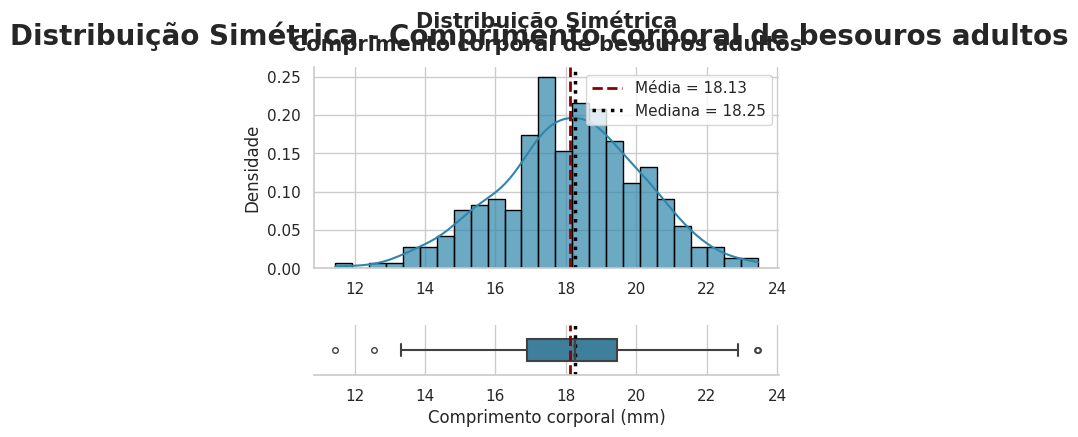

In [19]:
# --- Distribuição Simétrica ---
create_distribution_plots(
    dados_biologicos["Distribuição aproximadamente simétrica"],
    "Distribuição Simétrica"
)


/tmp/ipykernel_2472/488068196.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


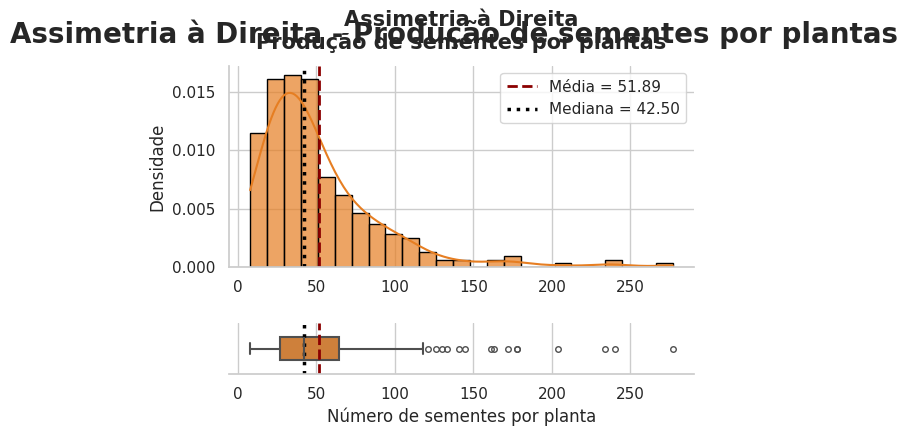

In [13]:
# --- Assimetria à Direita ---
create_distribution_plots(
    dados_biologicos["Assimetria à direita"],
    "Assimetria à Direita"
)



/tmp/ipykernel_2472/488068196.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


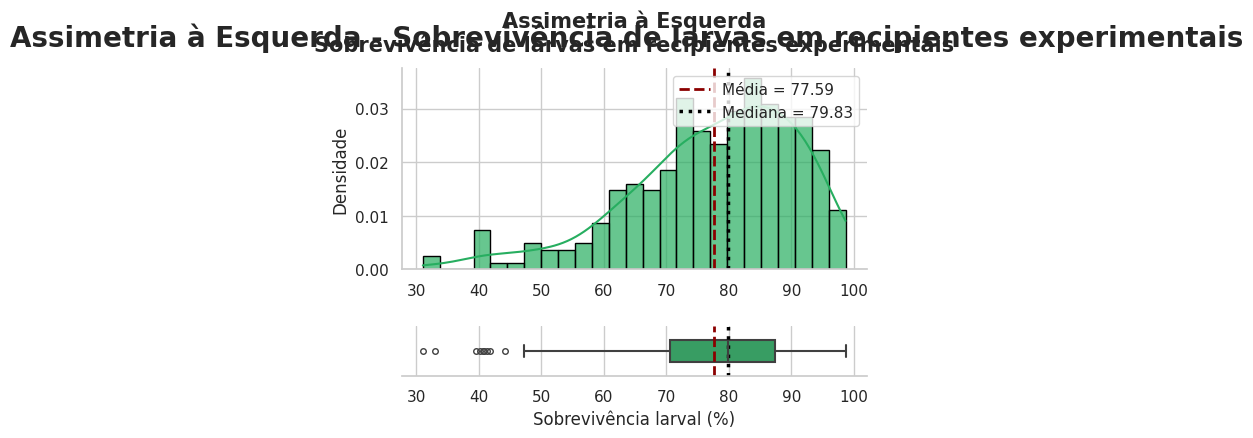

In [14]:
# --- Assimetria à Esquerda ---
create_distribution_plots(
    dados_biologicos["Assimetria à esquerda"],
    "Assimetria à Esquerda"
)


# INTERPRETAÇÃO DIDÁTICA SUGERIDA


# 1. DISTRIBUIÇÃO SIMÉTRICA
    - O histograma tende a ter lados semelhantes.
    - A média e a mediana ficam próximas.
    - O boxplot tende a apresentar a mediana aproximadamente no centro da caixa.

# 2. ASSIMETRIA À DIREITA (POSITIVA)
    - A maior parte dos valores fica em posições menores.
    - Há uma cauda longa em direção aos valores altos.
    - A média é puxada para a direita pelos valores elevados.
    - Em geral: média > mediana.
    - No boxplot, a haste direita tende a ser maior e podem surgir
      valores extremos no lado direito.

# 3. ASSIMETRIA À ESQUERDA (NEGATIVA)
    - A maior parte dos valores fica em posições elevadas.
    - Há uma cauda longa em direção aos valores baixos.
    - A média é puxada para a esquerda pelos valores pequenos.
    - Em geral: média < mediana.
    - No boxplot, a haste esquerda tende a ser maior e podem surgir
      valores extremos no lado esquerdo.

